### **QUESTION 6**

6. Run notebooks/07_ebm/01_ebm/ebm.ipynb. Clearly comment before each line of the code and
understand / analyze the output. Share the coleb link


In [1]:
# Import sys module to check runtime environment (e.g., Colab or local)
import sys


# If running inside Google Colab, download required helper utilities from GitHub
if 'google.colab' in sys.modules:

    # Download utils.py from official GitHub repository
    !wget https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/notebooks/utils.py

    # Create a folder named 'notebooks' if it doesn't exist
    !mkdir -p notebooks

    # Move downloaded utils.py into notebooks folder
    !mv utils.py notebooks

    # Create directory to store generated outputs (images, samples, etc.)
    !mkdir output

    # Create directory to save trained models / checkpoints
    !mkdir models

--2026-04-16 11:31:08--  https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/notebooks/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 771 [text/plain]
Saving to: ‘utils.py’

utils.py            100%[===================>]     771  --.-KB/s    in 0s      

2026-04-16 11:31:08 (50.8 MB/s) - ‘utils.py’ saved [771/771]



In [2]:
# NumPy for numerical operations and array handling
import numpy as np

# TensorFlow core library for deep learning
import tensorflow as tf

# Keras modules for building and training models
from tensorflow.keras import (
    datasets,     # built-in datasets (e.g., MNIST, CIFAR)
    layers,       # neural network layers
    models,       # model definition (Functional / Sequential / Subclassing)
    optimizers,   # optimization algorithms (Adam, SGD, etc.)
    activations,  # activation functions (ReLU, Sigmoid, etc.)
    metrics,      # evaluation metrics
    callbacks,    # training utilities (checkpoint, early stopping, etc.)
)

# Custom utilities for visualization and batch sampling
from notebooks.utils import display, sample_batch

# Python random module for reproducibility / random sampling
import random

In [3]:
# Target image size for PixelCNN (32x32 images)
IMAGE_SIZE = 32

# Number of image channels (1 = grayscale, 3 = RGB)
CHANNELS = 1

# Step size for sampling / generation process
STEP_SIZE = 10

# Number of sampling steps in image generation
STEPS = 60

# Small noise added during sampling for stability
NOISE = 0.005

# Alpha parameter controlling sampling randomness / mixing strength
ALPHA = 0.1

# Gradient clipping threshold to stabilize training
GRADIENT_CLIP = 0.03

# Number of images processed per training batch
BATCH_SIZE = 128

# Buffer size for shuffling dataset
BUFFER_SIZE = 8192

# Learning rate for optimizer
LEARNING_RATE = 0.0001

# Total number of training epochs
EPOCHS = 60

# Whether to load a pre-trained model instead of training from scratch
LOAD_MODEL = False

In [4]:
# Load MNIST dataset (digits images, labels ignored for generative model)
(x_train, _), (x_test, _) = datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Normalize images to [-1, 1], pad to 32x32, add channel dimension
def preprocess(imgs):
    imgs = (imgs.astype("float32") - 127.5) / 127.5
    imgs = np.pad(imgs, ((0, 0), (2, 2), (2, 2)), constant_values=-1.0)
    imgs = np.expand_dims(imgs, -1)
    return imgs

# Apply preprocessing to train and test sets
x_train = preprocess(x_train)
x_test = preprocess(x_test)

In [6]:
# Convert numpy arrays into TensorFlow dataset and batch them
x_train = tf.data.Dataset.from_tensor_slices(x_train).batch(BATCH_SIZE)
x_test = tf.data.Dataset.from_tensor_slices(x_test).batch(BATCH_SIZE)

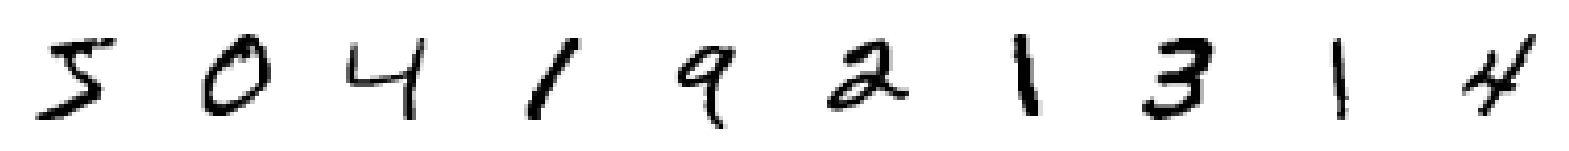

In [7]:
# Take a small batch of training images
train_sample = sample_batch(x_train)

# Display the sampled images
display(train_sample)

In [8]:
# Input image tensor
ebm_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS))

# Convolution stack to extract hierarchical features
x = layers.Conv2D(16, 5, strides=2, padding="same", activation=activations.swish)(ebm_input)
x = layers.Conv2D(32, 3, strides=2, padding="same", activation=activations.swish)(x)
x = layers.Conv2D(64, 3, strides=2, padding="same", activation=activations.swish)(x)
x = layers.Conv2D(64, 3, strides=2, padding="same", activation=activations.swish)(x)

# Flatten feature maps into vector
x = layers.Flatten()(x)

# Fully connected layer for representation learning
x = layers.Dense(64, activation=activations.swish)(x)

# Output single scalar energy score
ebm_output = layers.Dense(1)(x)

# Define Energy-Based Model (outputs energy score)
model = models.Model(ebm_input, ebm_output)

# Print model architecture
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,993 (300.75 KB)

 Trainable params: 76,993 (300.75 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Load saved model weights if flag is enabled
if LOAD_MODEL:
    model.load_weights("./models/model.h5")

In [10]:
# Generate samples using Langevin dynamics (EBM sampling)
def generate_samples(model, inp_imgs, steps, step_size, noise, return_img_per_step=False):

    imgs_per_step = []  # store intermediate images if needed

    for _ in range(steps):
        # Add small random noise (exploration)
        inp_imgs += tf.random.normal(inp_imgs.shape, mean=0, stddev=noise)

        # Keep pixel values in valid range [-1, 1]
        inp_imgs = tf.clip_by_value(inp_imgs, -1.0, 1.0)

        # Compute gradient of energy w.r.t. image
        with tf.GradientTape() as tape:
            tape.watch(inp_imgs)
            out_score = model(inp_imgs)

        grads = tape.gradient(out_score, inp_imgs)

        # Clip gradients for stability
        grads = tf.clip_by_value(grads, -GRADIENT_CLIP, GRADIENT_CLIP)

        # Update image using gradient ascent (move to lower energy region)
        inp_imgs += step_size * grads

        # Keep values in valid range
        inp_imgs = tf.clip_by_value(inp_imgs, -1.0, 1.0)

        # Save intermediate images if required
        if return_img_per_step:
            imgs_per_step.append(inp_imgs)

    # Return full trajectory or final samples
    if return_img_per_step:
        return tf.stack(imgs_per_step, axis=0)
    else:
        return inp_imgs

In [11]:
# Replay buffer to store and reuse generated samples (for stable EBM training)
class Buffer:
    def __init__(self, model):
        super().__init__()
        self.model = model

        # Initialize buffer with random images in range [-1, 1]
        self.examples = [
            tf.random.uniform(shape=(1, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2 - 1
            for _ in range(BATCH_SIZE)
        ]

    def sample_new_exmps(self, steps, step_size, noise):
        # Decide how many new random images to generate (5% new, rest from buffer)
        n_new = np.random.binomial(BATCH_SIZE, 0.05)

        # Generate new random images
        rand_imgs = tf.random.uniform((n_new, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2 - 1

        # Sample old images from buffer
        old_imgs = tf.concat(
            random.choices(self.examples, k=BATCH_SIZE - n_new), axis=0
        )

        # Combine new + old images
        inp_imgs = tf.concat([rand_imgs, old_imgs], axis=0)

        # Refine images using Langevin dynamics
        inp_imgs = generate_samples(
            self.model, inp_imgs, steps=steps, step_size=step_size, noise=noise
        )

        # Update buffer with new samples (keep recent ones)
        self.examples = tf.split(inp_imgs, BATCH_SIZE, axis=0) + self.examples
        self.examples = self.examples[:BUFFER_SIZE]

        # Return generated samples
        return inp_imgs

In [12]:
# Custom Energy-Based Model with contrastive divergence training
class EBM(models.Model):

    def __init__(self):
        super(EBM, self).__init__()

        # Base CNN energy model
        self.model = model

        # Replay buffer for negative samples
        self.buffer = Buffer(self.model)

        # Regularization strength
        self.alpha = ALPHA

        # Metrics to track training
        self.loss_metric = metrics.Mean(name="loss")
        self.reg_loss_metric = metrics.Mean(name="reg")
        self.cdiv_loss_metric = metrics.Mean(name="cdiv")
        self.real_out_metric = metrics.Mean(name="real")
        self.fake_out_metric = metrics.Mean(name="fake")

    @property
    def metrics(self):
        # Metrics returned during training
        return [
            self.loss_metric,
            self.reg_loss_metric,
            self.cdiv_loss_metric,
            self.real_out_metric,
            self.fake_out_metric,
        ]

    def train_step(self, real_imgs):
        # Add small noise to real images (stability)
        real_imgs += tf.random.normal(shape=tf.shape(real_imgs), mean=0, stddev=NOISE)
        real_imgs = tf.clip_by_value(real_imgs, -1.0, 1.0)

        # Generate fake images using buffer + Langevin dynamics
        fake_imgs = self.buffer.sample_new_exmps(
            steps=STEPS, step_size=STEP_SIZE, noise=NOISE
        )

        # Combine real and fake images
        inp_imgs = tf.concat([real_imgs, fake_imgs], axis=0)

        with tf.GradientTape() as training_tape:
            # Compute energy scores
            real_out, fake_out = tf.split(self.model(inp_imgs), 2, axis=0)

            # Contrastive divergence loss (push real ↓ energy, fake ↑ energy)
            cdiv_loss = tf.reduce_mean(fake_out, axis=0) - tf.reduce_mean(real_out, axis=0)

            # Regularization to prevent exploding energies
            reg_loss = self.alpha * tf.reduce_mean(real_out**2 + fake_out**2, axis=0)

            # Total loss
            loss = cdiv_loss + reg_loss

        # Compute gradients and update model
        grads = training_tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))

        # Update metrics
        self.loss_metric.update_state(loss)
        self.reg_loss_metric.update_state(reg_loss)
        self.cdiv_loss_metric.update_state(cdiv_loss)
        self.real_out_metric.update_state(tf.reduce_mean(real_out, axis=0))
        self.fake_out_metric.update_state(tf.reduce_mean(fake_out, axis=0))

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, real_imgs):
        # Generate random fake images (no buffer during testing)
        batch_size = real_imgs.shape[0]
        fake_imgs = tf.random.uniform((batch_size, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2 - 1

        # Combine real and fake
        inp_imgs = tf.concat([real_imgs, fake_imgs], axis=0)

        # Compute energy scores
        real_out, fake_out = tf.split(self.model(inp_imgs), 2, axis=0)

        # Contrastive divergence metric
        cdiv = tf.reduce_mean(fake_out, axis=0) - tf.reduce_mean(real_out, axis=0)

        # Update metrics
        self.cdiv_loss_metric.update_state(cdiv)
        self.real_out_metric.update_state(tf.reduce_mean(real_out, axis=0))
        self.fake_out_metric.update_state(tf.reduce_mean(fake_out, axis=0))

        return {m.name: m.result() for m in self.metrics[2:]}

In [13]:
ebm = EBM()

In [14]:
# Compile EBM with Adam optimizer (eager mode for custom training loop)
ebm.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    run_eagerly=True
)

In [15]:
# TensorBoard logging callback
tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


# Callback to generate sample images after each epoch
class ImageGenerator(callbacks.Callback):
    def __init__(self, num_img):
        self.num_img = num_img

    def on_epoch_end(self, epoch, logs=None):
        # Start from random noise images
        start_imgs = np.random.uniform(
            size=(self.num_img, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
        ) * 2 - 1

        # Generate refined images using Langevin sampling
        generated_images = generate_samples(
            ebm.model,
            start_imgs,
            steps=1000,
            step_size=STEP_SIZE,
            noise=NOISE,
            return_img_per_step=False,
        ).numpy()

        # Save generated images
        display(generated_images, save_to="./output/generated_img_%03d.png" % epoch)

        # Save buffer example images
        example_images = tf.concat(
            random.choices(ebm.buffer.examples, k=10), axis=0
        ).numpy()

        display(example_images, save_to="./output/example_img_%03d.png" % epoch)


# Create image generation callback
image_generator_callback = ImageGenerator(num_img=10)

In [16]:
# Callback to save model weights after each epoch
class SaveModel(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        model.save_weights("./models/model.h5")

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - cdiv: -0.0056 - fake: 0.0129 - loss: -0.0022 - real: 0.0185 - reg: 0.0034
Saved to ./output/generated_img_000.png


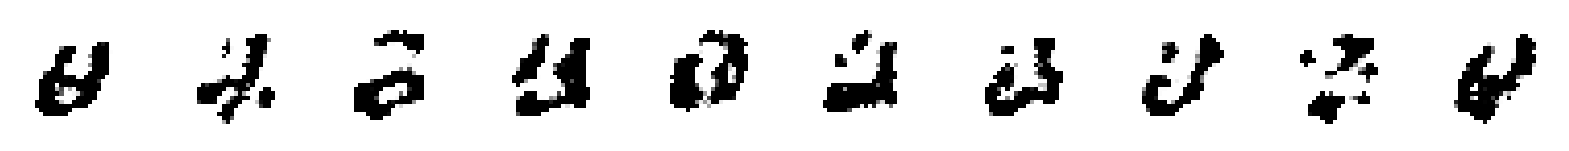


Saved to ./output/example_img_000.png


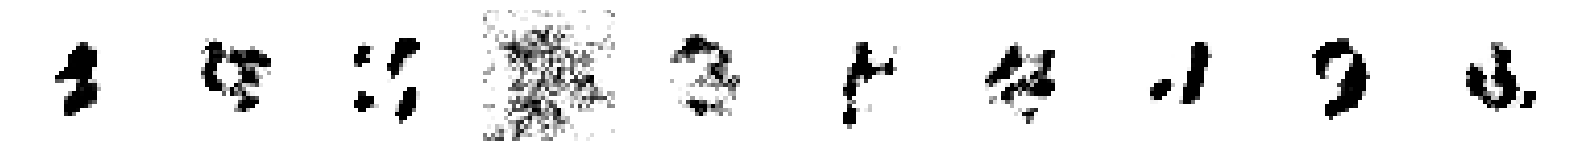

469/469 ━━━━━━━━━━━━━━━━━━━━ 784s 2s/step - cdiv: -0.0059 - fake: 0.0058 - loss: -0.0032 - real: 0.0116 - reg: 0.0027 - val_cdiv: -1.7437 - val_fake: -1.8423 - val_real: -0.0986
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - cdiv: -0.0037 - fake: 0.0043 - loss: -0.0019 - real: 0.0080 - reg: 0.0018
Saved to ./output/generated_img_001.png


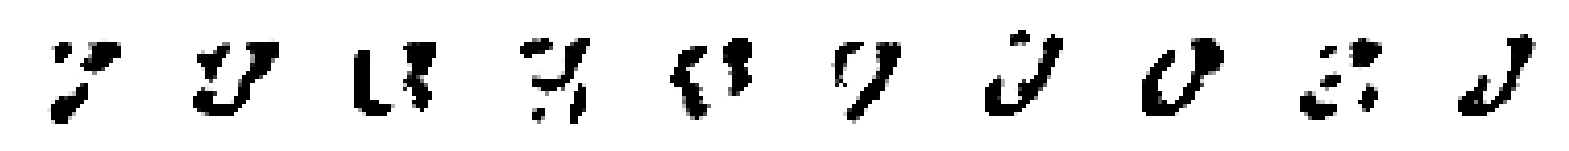


Saved to ./output/example_img_001.png


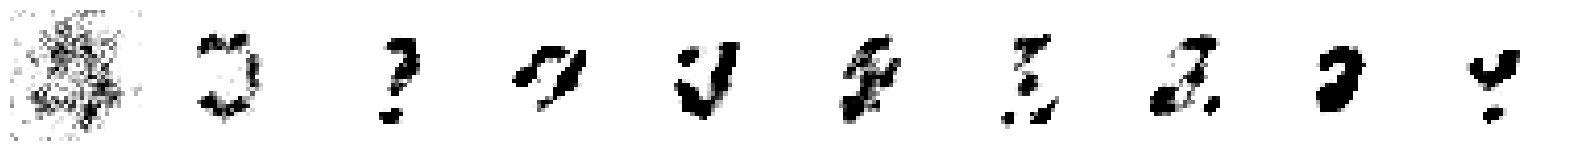

469/469 ━━━━━━━━━━━━━━━━━━━━ 781s 2s/step - cdiv: -0.0024 - fake: 0.0023 - loss: -0.0010 - real: 0.0048 - reg: 0.0014 - val_cdiv: -2.0047 - val_fake: -2.0519 - val_real: -0.0472
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - cdiv: -8.6875e-04 - fake: 0.0025 - loss: -5.3343e-05 - real: 0.0034 - reg: 8.1541e-04
Saved to ./output/generated_img_002.png


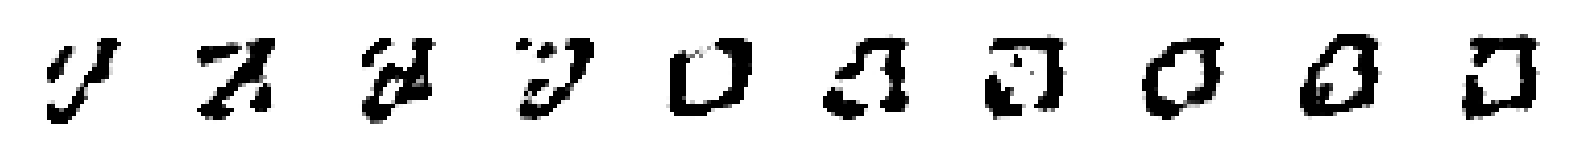


Saved to ./output/example_img_002.png


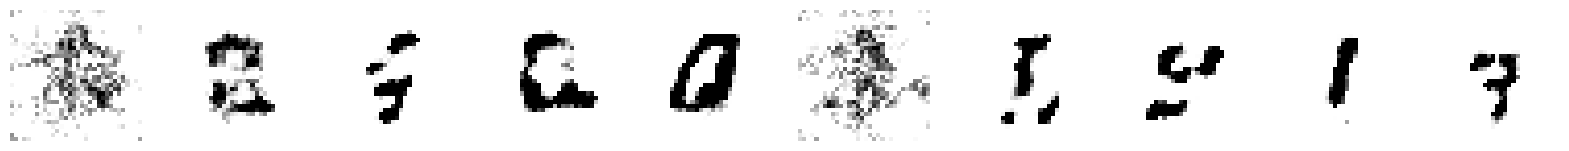

469/469 ━━━━━━━━━━━━━━━━━━━━ 784s 2s/step - cdiv: -2.2955e-04 - fake: 0.0014 - loss: 4.1348e-04 - real: 0.0016 - reg: 6.4303e-04 - val_cdiv: -2.1756 - val_fake: -2.2163 - val_real: -0.0408
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - cdiv: 3.9947e-04 - fake: 0.0018 - loss: 8.5648e-04 - real: 0.0014 - reg: 4.5701e-04
Saved to ./output/generated_img_003.png


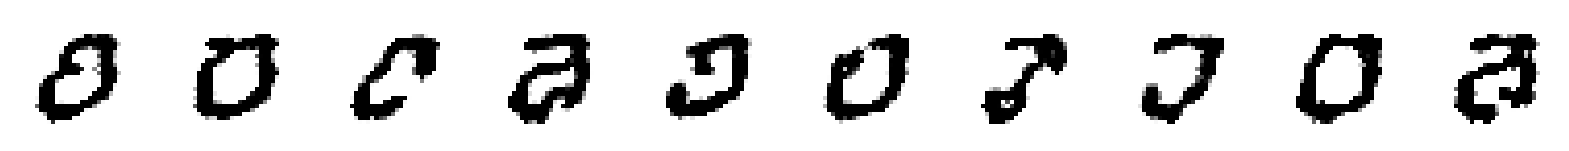


Saved to ./output/example_img_003.png


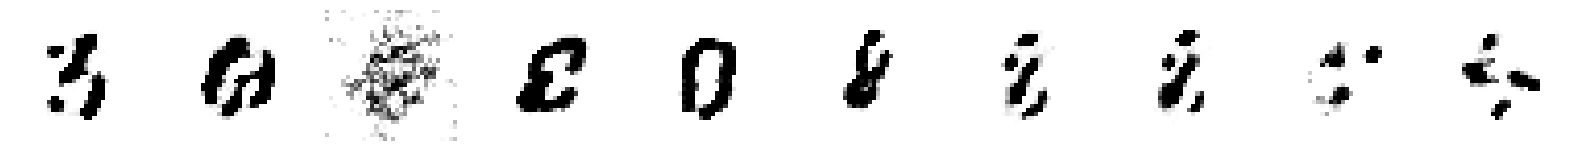

469/469 ━━━━━━━━━━━━━━━━━━━━ 792s 2s/step - cdiv: -1.8963e-05 - fake: 0.0014 - loss: 3.6719e-04 - real: 0.0014 - reg: 3.8616e-04 - val_cdiv: -2.3947 - val_fake: -2.4110 - val_real: -0.0163
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - cdiv: 7.2658e-04 - fake: 0.0013 - loss: 0.0011 - real: 5.3749e-04 - reg: 3.3657e-04
Saved to ./output/generated_img_004.png


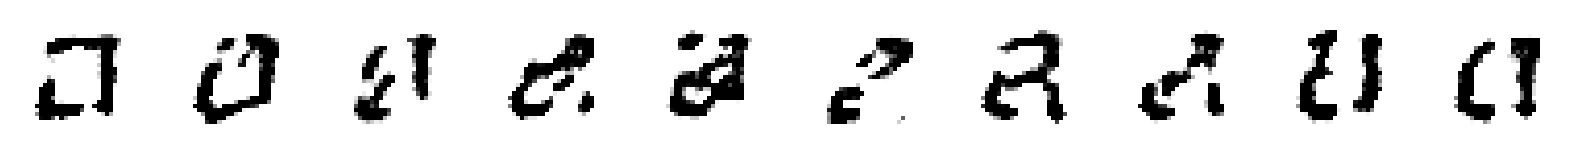


Saved to ./output/example_img_004.png


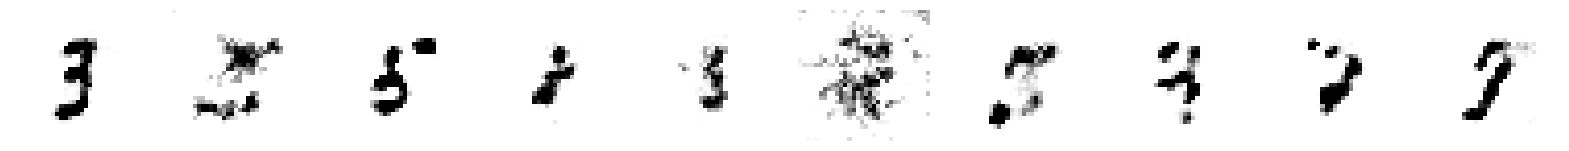

469/469 ━━━━━━━━━━━━━━━━━━━━ 775s 2s/step - cdiv: 2.0977e-04 - fake: 0.0017 - loss: 4.9610e-04 - real: 0.0015 - reg: 2.8632e-04 - val_cdiv: -2.7168 - val_fake: -2.7354 - val_real: -0.0186


In [19]:
# Callback to save model weights with correct filename
class SaveModel(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        model.save_weights("./models/model.weights.h5")


# Create callback
save_model_callback = SaveModel()


# Train model
ebm.fit(
    x_train,
    shuffle=True,
    epochs=5,
    validation_data=x_test,
    callbacks=[
        save_model_callback,
        tensorboard_callback,
        image_generator_callback,
    ],
)

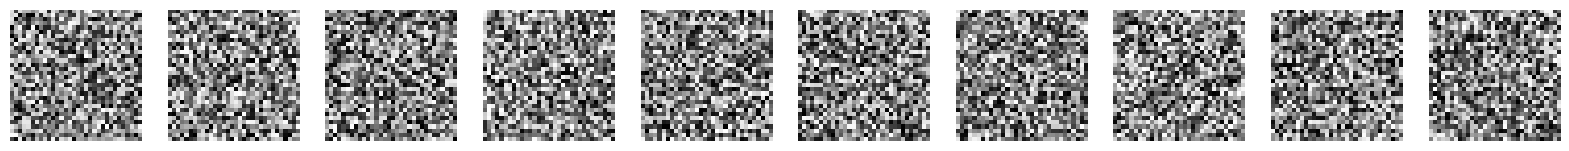

In [20]:
# Generate random noise images in range [-1, 1]
start_imgs = (
    np.random.uniform(size=(10, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2 - 1
)

# Display noise images (starting point for generation)
display(start_imgs)

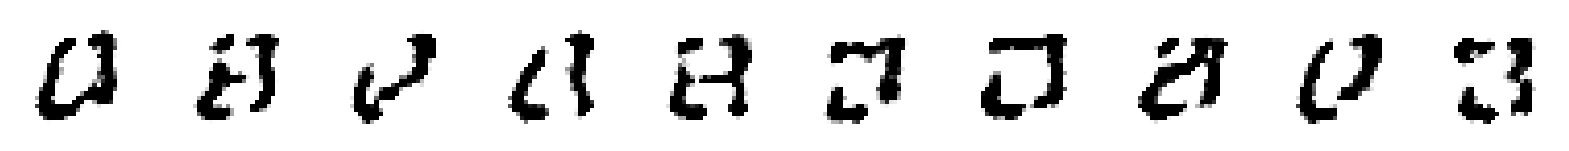

In [21]:
# Generate images using Langevin dynamics (step-by-step refinement)
gen_img = generate_samples(
    ebm.model,
    start_imgs,
    steps=1000,
    step_size=STEP_SIZE,
    noise=NOISE,
    return_img_per_step=True,
)

# Display final generated images after all refinement steps
display(gen_img[-1].numpy())

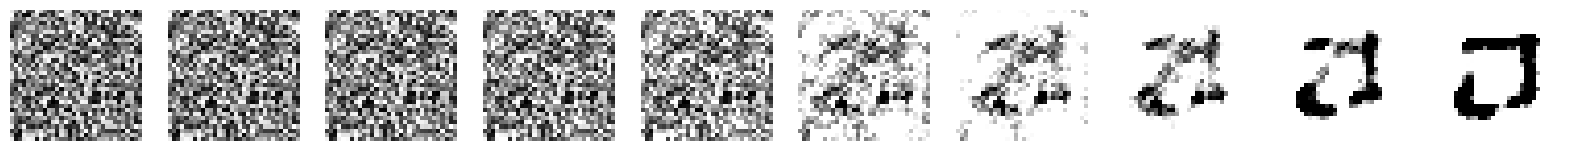

In [22]:
# Select specific sampling steps to visualize generation process
imgs = []
for i in [0, 1, 3, 5, 10, 30, 50, 100, 300, 999]:
    # Take 7th image from batch at each step
    imgs.append(gen_img[i].numpy()[6])

# Display how one image evolves over time
display(np.array(imgs))

The model generates images using Langevin dynamics, starting from random noise and gradually refining it into meaningful digit-like structures.
One part of the code visualizes the step-by-step evolution of a single image, showing how noise slowly becomes a clear digit over multiple sampling steps.
Another part runs the full iterative sampling process (1000 steps) to progressively improve all images using energy gradients.
The final output shows fully generated MNIST-like digits, which are the result of repeated refinement.

**CONCLUSION**
* This code builds an **Energy-Based Model (EBM)** that learns a function assigning **low energy to real MNIST images** and **high energy to fake (generated) images**.
* The model uses a **CNN-based architecture** that outputs a single scalar energy score instead of predicting pixel probabilities like PixelCNN or PixelCNN-MD.
* It is trained using **contrastive divergence**, where the loss pushes real images toward lower energy and generated images toward higher energy.
* Image generation is performed using **Langevin dynamics**, where random noise is gradually refined using gradients of the energy function along with small injected noise.
* A **replay buffer** stores previously generated samples and reuses them during training to improve stability and prevent the model from forgetting earlier patterns.
* The generation process is **iterative**, meaning images slowly evolve from noise into structured digits over many steps instead of being produced in one pass.
* Visualization callbacks show how images transform from random noise into clear MNIST digits across training epochs.
* Compared to **PixelCNN and PixelCNN-MD**, which model explicit pixel-wise probability distributions and are more stable, this EBM learns an **implicit energy landscape**, making it more flexible but harder and less stable to train.
* Overall, the model demonstrates how realistic data distributions can emerge by learning to shape an energy surface where real images lie in low-energy regions.
